# Numpy vs Pandas: Exercises

We explore a numerical dataset freely avaible under MIT license on Kaggle, a platform for data science competitions and datasets. 

The dataset focuses on solar system objects and contains several attributes.

In [2]:
import pandas as pd 

df = pd.read_csv("kaggle_solar/sol_data.csv")
df

,eName,isPlanet,semimajorAxis,perihelion,aphelion,eccentricity,inclination,density,gravity,escape,...,orbits,bondAlbido,geomAlbido,RV_abs,p_transit,transit_visibility,transit_depth,massj,semimajorAxis_AU,grav_int
0,Moon,False,384400,363300,405500,0.0549,5.145,3.344,1.6200,2380.000,...,Earth,NaN,NaN,NaN,1.811589,326.086108,2.245860e-09,3.868421e-05,0.002570,6.606324e+25
1,Phobos,False,9376,9234,9518,0.0151,1.075,1.900,0.0057,11.390,...,Mars,NaN,NaN,NaN,74.272078,13368.973976,2.245860e-09,5.578947e-12,0.000063,1.601437e+22
2,Deimos,False,23458,23456,23471,0.0002,1.075,1.750,0.0030,5.556,...,Mars,NaN,NaN,NaN,29.686035,5343.486231,2.245860e-09,1.263158e-12,0.000157,5.792534e+20
3,Io,False,421800,0,0,0.0040,0.036,3.530,1.7900,0.000,...,Jupiter,NaN,NaN,NaN,1.655200,297.936060,6.842474e-06,4.700000e-05,0.002820,6.666188e+25
4,Europa,False,671100,0,0,0.0090,0.466,3.010,1.3100,0.000,...,Jupiter,NaN,NaN,NaN,1.039939,187.188949,5.023997e-06,2.526316e-05,0.004486,1.415487e+25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,S/2017 J 8,False,23233000,0,0,0.3120,164.700,1.000,0.0000,0.000,...,Jupiter,NaN,NaN,NaN,0.029972,5.394983,5.155785e-13,1.263158e-11,0.155303,5.905272e+15
261,S/2017 J 9,False,21487000,0,0,0.2290,152.700,1.000,0.0000,0.000,...,Jupiter,NaN,NaN,NaN,0.032408,5.833380,4.640207e-12,1.263158e-11,0.143632,6.903971e+15
262,Ersa,False,11483000,0,0,0.0940,30.600,1.000,0.0000,0.000,...,Jupiter,NaN,NaN,NaN,0.060641,10.915425,4.640207e-12,1.263158e-11,0.076759,2.417351e+16
263,Ultima Thule,False,6633400000,0,0,0.0000,0.000,1.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000105,0.018896,2.245860e-09,1.263158e-11,44.341540,7.243995e+10


## Exercise 1: Extracting numpy arrays 

- Select the columns `semimajorAxis`, `density`, and `gravity` from the DataFrame `df` and convert them into a `numpy` array named `np_solar_data`. 
- Then, design a **test** (e.g. using an `if/else` statement or an `assert` statement) to verify that `np_solar_data` is indeed a `numpy` array. Notice that simply printing the type of `np_solar_data` is not a test!


**Reminder.** An `assert` statement is a way to test if a condition in your code returns `True`. If not, the program will raise an `AssertionError`. 

It uses the keyword `assert` followed by the condition to test and an optional error message.

```python
assert condition, "Error message if condition is False"
```
**Hint.** If the conversion to `numpy` array is correct, then the type of `np_solar_data` should be `np.ndarray`


In [3]:
## SOLUTION
import numpy as np
np_solar_data = df[['semimajorAxis','density','gravity']].to_numpy()
# checking that the conversion was successful (assertion)
assert type(np_solar_data) == np.ndarray, "The conversion was not successful"
# alternatively, you can use if/else
if type(np_solar_data) == np.ndarray:
    print("The conversion was successful")  
else:
    print("The conversion was not successful")

The conversion was successful


## Exercise 2: Extracting basic statistics

- Using the `numpy` array `np_solar_data` created in Exercise 1, compute the mean and standard deviation for each of the three columns: `semimajorAxis`, `density`, and `gravity`. Store the results in two separate `numpy` arrays named `mean_values` and `std_values`.
- Can you find  way to compute these same statistics from the original DataFrame `df` without converting it to a `numpy` array? Store these results in two separate `pandas` Series named `mean_series` and `std_series`.
- Inspect the stand deviations in the numpy and pandas result. Can you choose parameters such that the results are identical? 

In [4]:
## SOLUTION

# Compute mean and standard deviation using numpy array
mean_values = np.mean(np_solar_data, axis=0)
std_values = np.std(np_solar_data, axis=0)

# Compute the same statistics using pandas DataFrame
mean_series = df[['semimajorAxis', 'density', 'gravity']].mean()
# choose the ddof parameter to match numpy's default behavior
std_series = df[['semimajorAxis', 'density', 'gravity']].std(ddof=0)

print("Mean values using numpy array:", mean_values)
print("Mean values using pandas DataFrame:\n", mean_series)
print("Standard deviation using numpy array:", std_values)
print("Standard deviation using pandas DataFrame:\n", std_series)

Mean values using numpy array: [1.33074037e+09 1.14478906e+00 1.38359000e+00]
Mean values using pandas DataFrame:
 semimajorAxis    1.330740e+09
density          1.144789e+00
gravity          1.383590e+00
dtype: float64
Standard deviation using numpy array: [1.04659260e+10 6.10583948e-01 1.69026845e+01]
Standard deviation using pandas DataFrame:
 semimajorAxis    1.046593e+10
density          6.105839e-01
gravity          1.690268e+01
dtype: float64


## Exercise 3: Understanding Pandas `SettingWithCopyWarning`

You want to analyze only the rocky planets by creating a subset and adding a calculated column.

**Task:** 
- Create a subset `rocky_planets` from `df` filtering for `isPlanet == True` and `density > 3`
- Add a new column `mass_estimate` to `rocky_planets` calculated as `density * gravity` 
- Observe any warnings that pandas displays
- What does the warning mean? Why did it appear?

In [5]:
## SOLUTION

# Create subset for rocky planets
rocky_planets = df[(df['isPlanet'] == True) & (df['density'] > 3)]
print("Rocky planets found:", len(rocky_planets))
print(rocky_planets[['eName', 'density', 'gravity']])

# Try to add a new column - this triggers SettingWithCopyWarning
rocky_planets['mass_estimate'] = rocky_planets['density'] * rocky_planets['gravity']

print("\nAdded 'mass_estimate' column")
print(rocky_planets[['eName', 'mass_estimate']].head())

# The warning appears because pandas cannot guarantee whether:
# 1. You're modifying a view (changes might affect original df)
# 2. You're modifying a copy (changes won't affect original df)
# 
# The behavior is unpredictable! To avoid this, use .copy() explicitly:
# rocky_planets = df[(df['isPlanet'] == True) & (df['density'] > 3)].copy()

Rocky planets found: 4
       eName  density  gravity
239     Mars   3.9341     3.71
240  Mercury   5.4291     3.70
243    Earth   5.5136     9.80
244    Venus   5.2430     8.87

Added 'mass_estimate' column
       eName  mass_estimate
239     Mars      14.595511
240  Mercury      20.087670
243    Earth      54.033280
244    Venus      46.505410


/var/folders/k2/zvg_gcvj6dz5q4_t5p1n04240000gp/T/ipykernel_90818/124972536.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rocky_planets['mass_estimate'] = rocky_planets['density'] * rocky_planets['gravity']


## Exercise 4: When Views and Copies Actually Break Your Code

The warning is nice, but let's see actual unexpected behavior! You'll try to add a column categorizing planets as inner or outer solar system objects, but the code won't work as expected.

**Note.** There are two types of chained indexing, both problematic:

1. **Column-then-row**: `df['column'][condition] = value` (select column, then filter)
2. **Row-then-column**: `df[condition]['column'] = value` (filter rows, then select column)

Both create intermediate objects (potential copies) before assignment, so modifications may be lost!


- Reload the DataFrame: `df = pd.read_csv("kaggle_solar/sol_data.csv")`
- Filter for planets: `planets = df[df['isPlanet'] == True].copy()`
- Initialize a column: `planets['outer_planet'] = False`

- Try row-then-column chained indexing: `planets[planets['semimajorAxis'] > 5]['outer_planet'] = True`**Note:** Objects with semimajorAxis > 5 AU are beyond Jupiter's orbit (outer solar system).

- Check if it worked, then use `.loc[]` to do it correctly

In [6]:
## SOLUTION

# Reload the data to start fresh
df = pd.read_csv("kaggle_solar/sol_data.csv")
planets = df[df['isPlanet'] == True].copy()
planets['outer_planet'] = False

# WRONG WAY - Row-then-column chained indexing
# Step 1: planets[condition] returns a filtered DataFrame (might be a copy)
# Step 2: ['outer_planet'] = True modifies that temporary copy, not planets!
planets[planets['semimajorAxis'] > 5]['outer_planet'] = True

print("WRONG WAY - After row-then-column chained indexing:")
print(planets[['eName', 'semimajorAxis', 'outer_planet']])
print("All values still False! Assignment was lost.\n")

# RIGHT WAY - Use .loc[rows, column] to do both selections at once
planets.loc[planets['semimajorAxis'] > 5, 'outer_planet'] = True

print("RIGHT WAY - After using .loc[]:")
print(planets[['eName', 'semimajorAxis', 'outer_planet']])
print("Jupiter, Saturn, Uranus, Neptune are now True!")

# Chained indexing (both types) creates intermediate objects between selections
# .loc[rows, columns] does selection and assignment in one atomic operation

WRONG WAY - After row-then-column chained indexing:
               eName  semimajorAxis  outer_planet
179          1 Ceres      413690250         False
187      136199 Eris    10180122852         False
199           Uranus     2870658186         False
208            Pluto     5906440628         False
219          Neptune     4498396441         False
222    136108 Haumea     6432011461         False
236  136472 Makemake     6783345606         False
238          Jupiter      778340821         False
239             Mars      227943824         False
240          Mercury       57909227         False
241           Saturn     1426666422         False
243            Earth      149598262         False
244            Venus      108208475         False
All values still False! Assignment was lost.

RIGHT WAY - After using .loc[]:
               eName  semimajorAxis  outer_planet
179          1 Ceres      413690250          True
187      136199 Eris    10180122852          True
199           Uranus

In [7]:
planets.columns

Index(['eName', 'isPlanet', 'semimajorAxis', 'perihelion', 'aphelion',
       'eccentricity', 'inclination', 'density', 'gravity', 'escape',
       'meanRadius', 'equaRadius', 'polarRadius', 'flattening', 'dimension',
       'sideralOrbit', 'sideralRotation', 'discoveryDate', 'mass_kg', 'volume',
       'orbit_type', 'orbits', 'bondAlbido', 'geomAlbido', 'RV_abs',
       'p_transit', 'transit_visibility', 'transit_depth', 'massj',
       'semimajorAxis_AU', 'grav_int', 'outer_planet'],
      dtype='object')

## Exercise 5: extracting data and processing it with `numpy` and `matpltolib`

We now want to extract data and process it with `numpy` functions.

- Using `numpy` or `pandas` extract the escape velocity and the mass in kg for all the objects and plot them in a scatter plot using `matplotlib`.

- Consider that th escape velocity can be calculated as follows:

$$
v_{e s c}=\sqrt{2 g R}
$$

where:
- $g$ is the surface gravity
- $R$ is the radius of the object in 


- Improve your plotting to illustrate this relationship explicitly (e.g. by changing the scales, plotting guides to the eye, etc.). Note that the radius is in km, the escape veclocity is in m/s, and the gravity is in m/s².

/Users/ft14968/.pyenv/versions/3.12.7/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


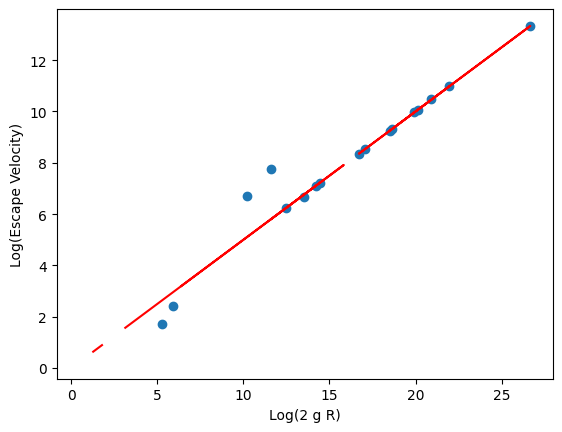

In [8]:
## SOLUTION

import matplotlib.pyplot as plt

x = np.log(2*df['gravity']*df['meanRadius']*1000)
y = np.log(df['escape'])
plt.scatter(x,y )
plt.xlabel('Log(2 g R)')
plt.ylabel('Log(Escape Velocity)')
plt.plot(x,0.5*x, 'r')


## Exercise 6: String Operations - Pandas vs NumPy

Extract planet names and convert them to uppercase using both pandas and numpy approaches.

**Task:**
- Filter the DataFrame to get only planets (where `isPlanet == True`)
- Extract the planet names (column `eName`) using pandas methods and convert them to uppercase (UPPERCASE). Store this in a variable named `pandas_upper_names`
- Now try to do the same using `numpy`: convert the `eName` column to a numpy array and apply string operations:

    - you can use a for loop to iterate through the names and convert them to uppercase (e.g. via list comprehension)
    - or use `numpy.char` sub module for vectorized string operations
 
- Which approach is easier for string operations?

In [13]:
## SOLUTION

# PANDAS approach - very clean and readable
planet_names_pandas = df[df['isPlanet'] == True]['eName'].str.upper()
print("Pandas approach:")
print(planet_names_pandas)

# NUMPY approach - requires more manual work
planets_mask = df['isPlanet'].to_numpy() == True
planet_names_numpy = df['eName'].to_numpy(dtype=str)[planets_mask]
# Need to use a list comprehension or np.char for string operations
planet_names_upper_numpy = np.char.upper(planet_names_numpy)
print("\nNumPy approach:")
print(planet_names_upper_numpy)

# Alternative numpy approach with list comprehension
planet_names_upper_list = [name.upper() for name in planet_names_numpy]
print("\nNumPy with list comprehension:")
print(planet_names_upper_list)

# Pandas is much more convenient for string operations!
# The .str accessor provides many built-in string methods

Pandas approach:
179            1 CERES
187        136199 ERIS
199             URANUS
208              PLUTO
219            NEPTUNE
222      136108 HAUMEA
236    136472 MAKEMAKE
238            JUPITER
239               MARS
240            MERCURY
241             SATURN
243              EARTH
244              VENUS
Name: eName, dtype: object

NumPy approach:
['1 CERES' '136199 ERIS' 'URANUS' 'PLUTO' 'NEPTUNE' '136108 HAUMEA'
 '136472 MAKEMAKE' 'JUPITER' 'MARS' 'MERCURY' 'SATURN' 'EARTH' 'VENUS']

NumPy with list comprehension:
['1 CERES', '136199 ERIS', 'URANUS', 'PLUTO', 'NEPTUNE', '136108 HAUMEA', '136472 MAKEMAKE', 'JUPITER', 'MARS', 'MERCURY', 'SATURN', 'EARTH', 'VENUS']


## Exercise 7: Grouping and Aggregation - Pandas vs NumPy

Calculate the mean density for planets vs non-planets using pandas groupby, then try to replicate this in numpy.

**Task:**
- Use pandas `groupby()` to compute the mean density grouped by `isPlanet` (True/False)
- Now try to replicate this result using only numpy arrays:
  - Convert the relevant columns to numpy arrays
  - Manually separate the data into two groups (planets and non-planets)
  - Calculate the mean for each group
  
- Which approach is more convenient? What happens if you need to group by multiple columns?

In [15]:
## SOLUTION

# PANDAS approach - simple and elegant
mean_density_by_planet = df.groupby('isPlanet')['density'].mean()
print("Pandas groupby approach:")
print(mean_density_by_planet)
print()

# NUMPY approach - manual and verbose
# Convert to numpy arrays
is_planet_array = df['isPlanet'].to_numpy()
density_array = df['density'].to_numpy()

# Manually create masks for each group
planets_mask = is_planet_array == True
non_planets_mask = is_planet_array == False

# Calculate mean for each group
mean_density_planets = np.mean(density_array[planets_mask])
mean_density_non_planets = np.mean(density_array[non_planets_mask])

print("NumPy manual approach:")
print(f"isPlanet = True:  {mean_density_planets}")
print(f"isPlanet = False: {mean_density_non_planets}")
print()

# For multiple groups or multiple columns, numpy becomes very cumbersome
# Pandas automatically handles group labels, missing values, etc.

Pandas groupby approach:
isPlanet
False    1.062528
True     2.739392
Name: density, dtype: float64

NumPy manual approach:
isPlanet = True:  2.7393923076923077
isPlanet = False: 1.0625277777777777



## Exercise 8: Correlation Matrix - Pandas vs NumPy

Calculate the correlation matrix for physical properties using pandas and numpy.

**Background:** 

The **covariance** between two variables $X$ and $Y$ measures how they vary together:
$$\text{cov}(X,Y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

The **correlation coefficient** normalizes covariance by the standard deviations:
$$r_{XY} = \frac{\text{cov}(X,Y)}{\sigma_X \sigma_Y}$$
where $\sigma_X = \sqrt{\frac{1}{n-1}\sum(x_i - \bar{x})^2}$ is the standard deviation.

Correlation ranges from -1 (perfect negative) to +1 (perfect positive), with 0 meaning no linear relationship.

**Standardization:** Transform each variable to have mean = 0 and standard deviation = 1:
$$z_i = \frac{x_i - \bar{x}}{\sigma_x}$$

After standardization, the correlation matrix can be computed using matrix multiplication.

**Task:**

- Use pandas `.corr()` to compute the correlation matrix for `density`, `gravity`, and `meanRadius`
- Now replicate this using `numpy` by following these steps:
  1. **Extract data**: Get the three columns as an $n \times 3$ matrix $X$ (n rows/objects, 3 columns/variables)
  2. **Center the data**: Subtract the mean of each column to get $X_{\text{centered}}$ (remember that you can use the `axis` parameter in `numpy` functions)
  3. **Standardize**: Divide each centered column by its standard deviation to get $Z$ (the standardized matrix)
  4. **Compute correlation**: The correlation matrix is $R = \frac{1}{n-1} Z^T Z$ (a $3 \times 3$ matrix)
  5. Compare with the pandas result
  
**Note:** The matrix $Z$ has shape $(n \times 3)$, so $Z^T$ has shape $(3 \times n)$, and their product gives a $(3 \times 3)$ correlation matrix.

In [16]:
## SOLUTION

# PANDAS approach - one line!
columns_of_interest = ['density', 'gravity', 'meanRadius']
corr_matrix_pandas = df[columns_of_interest].corr()
print("Pandas correlation matrix:")
print(corr_matrix_pandas)
print()

# NUMPY approach - manual calculation
# Step 1: Extract the data as numpy array
data = df[columns_of_interest].to_numpy()
print(f"Data shape: {data.shape} (rows x columns)")

# Step 2: Standardize each column (mean=0, std=1)
# Subtract mean from each column
data_centered = data - np.mean(data, axis=0)
# Divide by standard deviation
data_standardized = data_centered / np.std(data, axis=0, ddof=1)
print(f"Standardized data has mean ~0 and std ~1")
print(f"Means: {np.mean(data_standardized, axis=0)}")
print(f"Stds: {np.std(data_standardized, axis=0, ddof=1)}")
print()

# Step 3: Compute correlation matrix
# For standardized data: correlation = (1/(n-1)) * X^T @ X
n = data.shape[0]
corr_matrix_numpy = (1 / (n - 1)) * (data_standardized.T @ data_standardized)
print("NumPy correlation matrix:")
print(corr_matrix_numpy)
print()

# Step 4: Compare - they should be essentially identical
print("Difference between pandas and numpy results:")
print(corr_matrix_pandas.values - corr_matrix_numpy)
print("\nKey insight: Pandas .corr() does all the standardization internally!")
print("The correlation matrix is symmetric and diagonal elements are 1.0")

Pandas correlation matrix:
             density   gravity  meanRadius
density     1.000000  0.072885    0.039565
gravity     0.072885  1.000000    0.998144
meanRadius  0.039565  0.998144    1.000000

Data shape: (265, 3) (rows x columns)
Standardized data has mean ~0 and std ~1
Means: [1.74284067e-16 6.70323336e-18 6.70323336e-18]
Stds: [1. 1. 1.]

NumPy correlation matrix:
[[1.         0.07288471 0.03956538]
 [0.07288471 1.         0.99814417]
 [0.03956538 0.99814417 1.        ]]

Difference between pandas and numpy results:
[[-1.33226763e-15  0.00000000e+00  9.02056208e-17]
 [ 0.00000000e+00  8.88178420e-16  3.33066907e-16]
 [ 9.02056208e-17  3.33066907e-16 -4.44089210e-16]]

Key insight: Pandas .corr() does all the standardization internally!
The correlation matrix is symmetric and diagonal elements are 1.0


## Exercise 9: Creating a Theoretical Model Visualization with NumPy

Create a contour plot showing how escape velocity varies with surface gravity and radius, then overlay real solar system objects.

**Scientific Background:** 

From $v_{esc} = \sqrt{2gR}$, we can predict escape velocity for any combination of surface gravity $g$ and radius $R$. This creates a "phase space" showing where different types of objects fall.

**Task:**

1. **Create a grid of theoretical values using numpy:**
   - Use `np.linspace()` to create arrays of gravity values (0.1 to 30 m/s²) and radius values (100 to 100,000 km)
   - Use `np.meshgrid()` to create 2D grids for both variables
   - Calculate theoretical escape velocity on this grid using the formula (remember unit conversions!)

2. **Create a contour plot:**
   - Use `plt.contourf()` or `plt.contour()` to plot the theoretical escape velocity
   - Add contour labels showing escape velocity values
   - Filter the dataset for the 8 true planets: Mercury, Venus, Earth, Mars, Jupiter, Saturn, Uranus, Neptune
   - Overlay these planets on the contour plot using `plt.scatter()`

3. **Interpretation:**
   - Do the 8 planets fall on the theoretical contours?
   - Can you identify different groups among the planets (rocky vs gas/ice giants)?

Use the `matplotlib` documentation at https://matplotlib.org/stable/contents.html if needed.

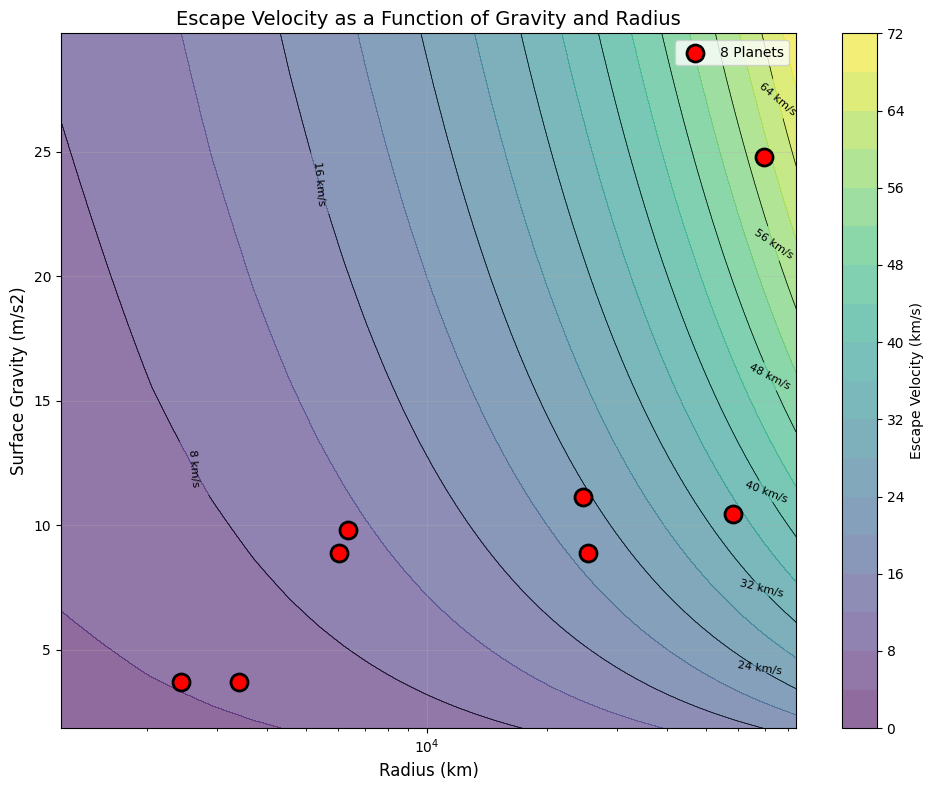

In [27]:
## SOLUTION

import matplotlib.pyplot as plt

# Filter for 8 true planets first
true_planets = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']
planets_data = df[df['eName'].isin(true_planets)]

# Extract ranges from the planet data
g_min, g_max = planets_data['gravity'].min(), planets_data['gravity'].max()
R_min, R_max = planets_data['meanRadius'].min(), planets_data['meanRadius'].max()

# Create 1D arrays for gravity and radius with some padding
g_values = np.linspace(g_min * 0.5, g_max * 1.2, 100)
R_values = np.linspace(R_min * 0.5, R_max * 1.2, 100)

# Create 2D meshgrids for contour plot
G_grid, R_grid = np.meshgrid(g_values, R_values)

# Calculate theoretical escape velocity
# Convert R from km to m, then result to km/s
V_esc_grid = np.sqrt(2 * G_grid * R_grid * 1000) / 1000

# Create the contour plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot filled contours and contour lines
contour_filled = ax.contourf(R_grid, G_grid, V_esc_grid, levels=20, cmap='viridis', alpha=0.6)
contour_lines = ax.contour(R_grid, G_grid, V_esc_grid, levels=10, colors='black', linewidths=0.5)
# Add labels to contour lines
ax.clabel(contour_lines, inline=True, fontsize=8, fmt='%0.0f km/s')

# Overlay planets
ax.scatter(planets_data['meanRadius'], planets_data['gravity'], 
           s=150, c='red', marker='o', edgecolors='black', linewidths=2,
           label='8 Planets', zorder=5)

# Labels and formatting
ax.set_xlabel('Radius (km)', fontsize=12)
ax.set_ylabel('Surface Gravity (m/s2)', fontsize=12)
ax.set_title('Escape Velocity as a Function of Gravity and Radius', fontsize=14)
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(contour_filled, ax=ax, label='Escape Velocity (km/s)')

plt.tight_layout()
plt.show()
